#GNN on QM9 Dataset
In this lab, we will build a graph neural network (GNN) to predict molecular properties from the QM9 dataset.

QM9 is a quantum chemistry dataset of small molecules containing C, H, O, N, and F, with each molecule having up to 9 heavy atoms. The dataset provides multiple electronic structure properties, all computed using density functional theory (DFT).

We will use the QM9 dataset available in the `torch-geometric` package, where the molecules are already represented as graph objects, ready for input into a GNN.

The description page of QM9 is [here](https://pytorch-geometric.readthedocs.io/en/2.6.1/generated/torch_geometric.datasets.QM9.html)

## Packages used:
`pytorch-geometric`: handles graph related tasks

`pytorch`: handles modeling and training

In [1]:
! pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.2 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import QM9
from torch_geometric.nn import MessagePassing, global_mean_pool

### Download the QM9 dataset

In [3]:
dataset = QM9(root='lab10/QM9')

Extracting lab10/QM9/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


### For this demo, we will use a small part of the whole dataset

In [4]:
dataset = dataset[:5000]

In [5]:
# Check what we have in the dataset
data_example = dataset[0]
print("Feature Matrix (node): ")
print(data_example.x)
print("Edge Index: ")
print(data_example.edge_index)
print("Edge Attributes:")
print(data_example.edge_attr)
print("Properties (y):")
print(data_example.y)

Feature Matrix (node): 
tensor([[0., 1., 0., 0., 0., 6., 0., 0., 0., 0., 4.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])
Edge Index: 
tensor([[0, 0, 0, 0, 1, 2, 3, 4],
        [1, 2, 3, 4, 0, 0, 0, 0]])
Edge Attributes:
tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]])
Properties (y):
tensor([[    0.0000,    13.2100,   -10.5499,     3.1865,    13.7363,    35.3641,
             1.2177, -1101.4878, -1101.4098, -1101.3840, -1102.0229,     6.4690,
           -17.1722,   -17.2868,   -17.3897,   -16.1519,   157.7118,   157.7100,
           157.7070]])


### We will only train the HOMO-LUMO gap in this demo, which is y[4]

In [6]:
gap_index = 4
# extract the gap values
# then reshape the y to [num_graphs, num_targets] shape
# usually we shouldn't directly change the y, but it is ok here...
dataset.data.y = dataset.data.y[:, gap_index].unsqueeze(1) # unsqueeze adds an extra dimension, 1: column is the new dimension

/tmp/ipython-input-3836102381.py:5: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  dataset.data.y = dataset.data.y[:, gap_index].unsqueeze(1) # unsqueeze adds an extra dimension, 1: column is the new dimension


### Train-Test Split

In [7]:
train_dataset = dataset[:4000]
test_dataset  = dataset[4000:]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # We can simply use DataLoader for batching
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Construct the GNN model
As discussed in the lecture. We will first define a single layer message passing model, and then define the whole GNN predictor.

#### Message-passing Layer

In [8]:
class MPNNLayer(MessagePassing):
    def __init__(self, node_dim, edge_dim):
        super().__init__(aggr='add')  # aggregation: sum, can also be 'mean', 'max', or 'mul'

        # define the NN for message function
        # input: features of the two connected node and the edge
        self.message_mlp = nn.Sequential(
            nn.Linear(2*node_dim + edge_dim, 64), # hidden layer is 64
            nn.ReLU(),
            nn.Linear(64, node_dim) # dim of message = dim of node features
        )

        # define the NN for node update function
        # input: old node feature and aggregated message
        self.update_mlp = nn.Sequential(
            nn.Linear(node_dim + node_dim, 64),
            nn.ReLU(),
            nn.Linear(64, node_dim)
        )

    # function to update the nodes
    # returns updated node features x
    # self.propagate() calls message(), aggregate() and update() functions
    def forward(self, x, edge_index, edge_attr):
        # x: node features [num_nodes, node_dim]
        # edge_index: [2, num_edges]
        # edge_attr: [num_edges, edge_dim]
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    # ---
    # The following two functions are standard in the MessagePassing class, and will be automatically called by self.propogate()
    # the message function
    def message(self, x_i, x_j, edge_attr):
        # x_i: receiver node, x_j: sender node
        m = torch.cat([x_i, x_j, edge_attr], dim=-1) # attach all the features
        return self.message_mlp(m)

    # the update function
    def update(self, aggr_out, x):
        # aggr_out: aggregated messages
        out = torch.cat([x, aggr_out], dim=-1)
        return self.update_mlp(out)

### GNN Predictor

In [9]:
class GNNPredictorModel(nn.Module):

    def __init__(self, node_dim, edge_dim, num_layers=3):
        '''
        num_layers defines how many layers we want to incorporate.
        '''
        super().__init__()
        # we use a simple affine function to do embedding.
        self.node_embedding = nn.Linear(11, node_dim)  # QM9 has 11 atom features
        self.layers = nn.ModuleList([MPNNLayer(node_dim, edge_dim) for _ in range(num_layers)]) # attach 3 MPNNLayer models

        # define the readout NN
        self.readout = nn.Sequential(
            nn.Linear(node_dim, 64), # message is of the same dim of node features
            nn.ReLU(),
            nn.Linear(64, 1) # predicting a number
        )

    def forward(self, data):
        # QM9 data here is already in graph representation
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.node_embedding(x)

        # update node features in each layer
        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)

        # Graph-level readout
        x = global_mean_pool(x, batch) # evaluate the mean
        y_pred = self.readout(x)
        return y_pred

### Let's start training!

In [10]:
# initialize the model, optimizer, and loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNNPredictorModel(node_dim=64, edge_dim=4, num_layers=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

#### We will wrap the training and test loops into a function

In [11]:
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)



In [12]:
def test(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

### Call train()

In [14]:
train_losses = []
test_losses = []
num_epochs = 10

for epoch in range(1, num_epochs+1):
    train_loss = train()
    test_loss = test(test_loader)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f'Epoch {epoch:02d}, Train MSE: {train_loss:.4f}, Test MSE: {test_loss:.4f}')

Epoch 01, Train MSE: 1.1111, Test MSE: 0.5112
Epoch 02, Train MSE: 1.0184, Test MSE: 0.5024
Epoch 03, Train MSE: 1.0395, Test MSE: 0.3975
Epoch 04, Train MSE: 0.8786, Test MSE: 0.8450
Epoch 05, Train MSE: 0.9564, Test MSE: 1.6660
Epoch 06, Train MSE: 0.8286, Test MSE: 0.6730
Epoch 07, Train MSE: 0.7264, Test MSE: 0.9311
Epoch 08, Train MSE: 0.7536, Test MSE: 0.6826
Epoch 09, Train MSE: 0.6990, Test MSE: 0.4508
Epoch 10, Train MSE: 0.6999, Test MSE: 1.2648


In [15]:
# visualize the training progress
from matplotlib import pyplot as plt

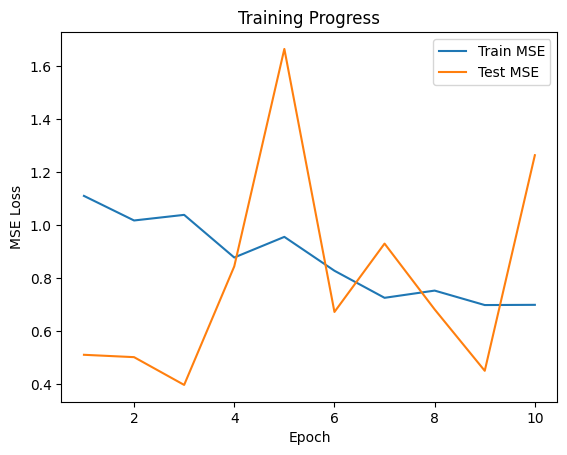

In [16]:
plt.plot(range(1, num_epochs+1), train_losses, label='Train MSE')
plt.plot(range(1, num_epochs+1), test_losses, label='Test MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Progress')
plt.legend()